## SVM Kernels Indepth Intuition ANd Practical Explanation 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(-5.0,5.0,100)
y=np.sqrt(10 **2 - x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x])

In [3]:
x1=np.linspace(-5.0,5.0,100)
y1=np.sqrt(5**2,x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])


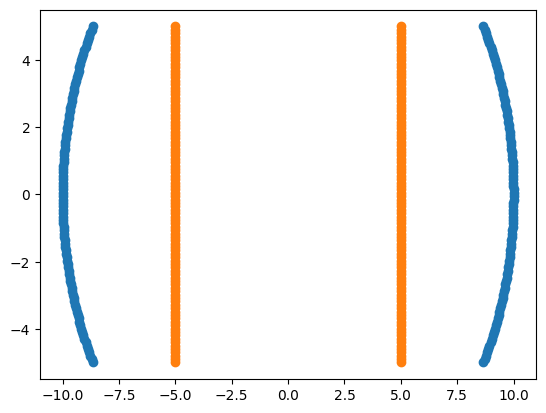

In [5]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [7]:
import pandas as pd
df1=pd.DataFrame(np.vstack([x,y]).T,columns=['x1','x2'])
df1['Y']=0
df2=pd.DataFrame(np.vstack([y1,x1]).T,columns=['x1','x2'])
df2['Y']=1


In [8]:
df1

,x1,x2,Y
0,-5.00000,8.660254,0
1,-4.89899,8.717792,0
2,-4.79798,8.773790,0
3,-4.69697,8.828277,0
4,-4.59596,8.881281,0
...,...,...,...
195,-4.59596,-8.881281,0
196,-4.69697,-8.828277,0
197,-4.79798,-8.773790,0
198,-4.89899,-8.717792,0


In [9]:
df2

,x1,x2,Y
0,5.0,-5.00000,1
1,5.0,-4.89899,1
2,5.0,-4.79798,1
3,5.0,-4.69697,1
4,5.0,-4.59596,1
...,...,...,...
195,-5.0,-4.59596,1
196,-5.0,-4.69697,1
197,-5.0,-4.79798,1
198,-5.0,-4.89899,1


In [10]:
df=pd.concat([df1,df2],axis=0,ignore_index=True)

In [16]:
df.head()

,x1,x2,Y
0,-5.00000,8.660254,0
1,-4.89899,8.717792,0
2,-4.79798,8.773790,0
3,-4.69697,8.828277,0
4,-4.59596,8.881281,0


In [24]:
## Independent and Dependent Features 

x=df.iloc[:, :2]
y=df.Y

In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)


In [29]:
# We need to find components for the ploynomial kernel 
# x1,x2,x1_square,x1*x2

df['x1_square']=df['x1']**2
df['x2_square']=df['x2']**2
df['x1*x2'] = (df['x1'] * df['x2'])
df.head()

,x1,x2,Y,x1_square,x2_square,x1*x2
0,-5.00000,8.660254,0,25.000000,75.000000,-43.301270
1,-4.89899,8.717792,0,24.000102,75.999898,-42.708375
2,-4.79798,8.773790,0,23.020610,76.979390,-42.096467
3,-4.69697,8.828277,0,22.061524,77.938476,-41.466150
4,-4.59596,8.881281,0,21.122845,78.877155,-40.818009


In [32]:
### Independent and Dependent features
x=df[['x1','x2','x1_square','x2_square','x1*x2']]
y=df['Y']

In [34]:
x.head()

,x1,x2,x1_square,x2_square,x1*x2
0,-5.00000,8.660254,25.000000,75.000000,-43.301270
1,-4.89899,8.717792,24.000102,75.999898,-42.708375
2,-4.79798,8.773790,23.020610,76.979390,-42.096467
3,-4.69697,8.828277,22.061524,77.938476,-41.466150
4,-4.59596,8.881281,21.122845,78.877155,-40.818009


In [35]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Y, dtype: int64

In [37]:
## Divide the data into train test split 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=8)

In [45]:
import plotly.express as px



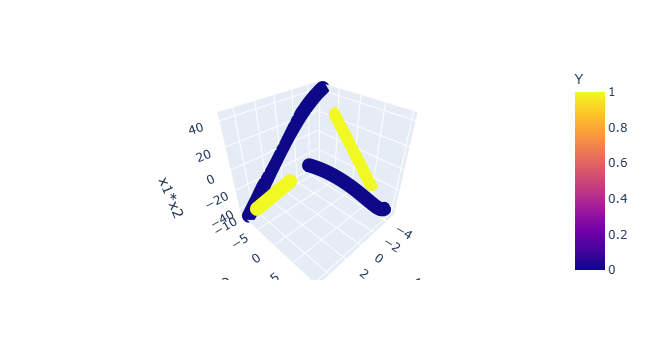

In [46]:
fig=px.scatter_3d(df,x='x1',y='x2',z='x1*x2',color='Y')
fig.show()

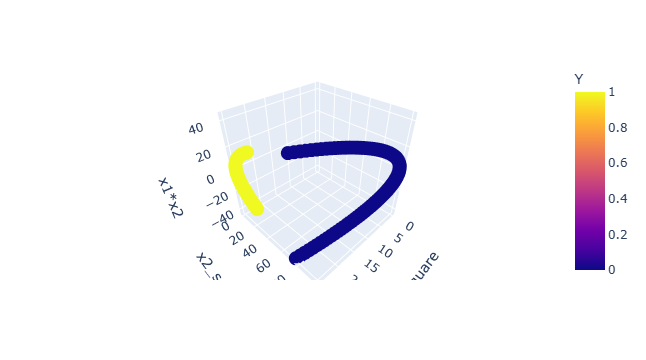

In [47]:
fig=px.scatter_3d(df,x='x1_square',y='x2_square',z='x1*x2',color='Y')
fig.show()

In [48]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel='linear')
classifier.fit(x_train,y_train)
y_pred=classifier.predict(x_test)
accuracy_score(y_test,y_pred)

1.0

In [49]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel='poly')
classifier.fit(x_train,y_train)
y_pred=classifier.predict(x_test)
accuracy_score(y_test,y_pred)

1.0

In [50]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel='sigmoid')
classifier.fit(x_train,y_train)
y_pred=classifier.predict(x_test)
accuracy_score(y_test,y_pred)

1.0

In [51]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel='rbf')
classifier.fit(x_train,y_train)
y_pred=classifier.predict(x_test)
accuracy_score(y_test,y_pred)

1.0